In [25]:
!pip install -q tensorflow
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, MaxPooling1D, Dense, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.models import Model
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



In [26]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1') # Latin1
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [27]:
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1) #colunas nao relevantes
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [28]:
df.columns = ['labels', 'data'] #renomeia as colunas
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [29]:
df['b_labels'] = df['labels'].map({'ham': 0, 'spam': 1}) # binariza como normal 0 ou spam 1 em uma nova coluna
Y = df['b_labels'].values
df.head()

,labels,data,b_labels
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [30]:
df_train, df_test, Ytrain, Ytest = train_test_split(df['data'], Y, test_size=0.33)

In [31]:
MAX_VOCAB_SIZE = 20000  # define o tamanho maximo do vocabulario
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)  # cria o tokenizador limitado ao tamanho maximo
tokenizer.fit_on_texts(df_train)  # ajusta o tokenizador nos dados de treino
sequences_train = tokenizer.texts_to_sequences(df_train)  # converte textos de treino em sequencias de inteiros
sequences_test = tokenizer.texts_to_sequences(df_test)  # converte textos de teste em sequencias de inteiros


In [32]:
word2idx = tokenizer.word_index  # dicionario que mapeia palavras para indices
V = len(word2idx)  # quantidade total de palavras no vocabulario
print('%s unique tokens.' % V)

7056 unique tokens.


In [42]:
data_train = pad_sequences(sequences_train)
print('Shape of data train tensor:', data_train.shape)

T = data_train.shape[1]

Shape of data train tensor: (3733, 189)


## palavras mais frequentes

In [41]:
from collections import Counter

word_counts = tokenizer.word_counts  # dicionario palavra -> contagem

# ordena pelas palavras mais frequentes
most_common = Counter(word_counts).most_common(10)  # top 10 palavras

for word, count in most_common:
    print(f'{word}: {count}')

i: 1581
to: 1465
you: 1445
a: 943
the: 848
u: 768
and: 643
is: 584
in: 583
me: 537


In [43]:
data_test = pad_sequences(sequences_test, maxlen=T)  # preenche ou corta sequencias de teste para tamanho T
print('Shape of data test tensor:', data_test.shape)  # mostra o formato do tensor de teste


Shape of data test tensor: (1839, 189)


In [36]:
D = 20  # dimensao dos vetores de embedding

i = Input(shape=(T,))  # entrada com formato de sequencia de tamanho t
x = Embedding(V + 1, D)(i)  # camada de embedding que transforma indices em vetores
x = Conv1D(32, 3, activation='relu')(x)  # 32 filtros e janela de tamanho 3
x = MaxPooling1D(3)(x)  #janela de tamanho 3
x = Conv1D(64, 3, activation='relu')(x)  #64 filtros
x = MaxPooling1D(3)(x)  #
x = Conv1D(128, 3, activation='relu')(x)  #128 filtros
x = GlobalMaxPooling1D()(x)  # global max pooling para reduzir para um vetor fixo
x = Dense(1, activation='sigmoid')(x)  # sigmoide para classificacao binaria

model = Model(i, x)  # cria o modelo ligando a entrada i a saida x

In [44]:
model.compile(
  loss='binary_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [38]:
r = model.fit(
  data_train,
  Ytrain,
  epochs=5,
  validation_data=(data_test, Ytest)
)

Epoch 1/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8465 - loss: 0.4484 - val_accuracy: 0.9342 - val_loss: 0.2153
Epoch 2/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9597 - loss: 0.1307 - val_accuracy: 0.9734 - val_loss: 0.0938
Epoch 3/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9875 - loss: 0.0383 - val_accuracy: 0.9739 - val_loss: 0.0896
Epoch 4/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9962 - loss: 0.0114 - val_accuracy: 0.9799 - val_loss: 0.0865
Epoch 5/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9997 - loss: 0.0049 - val_accuracy: 0.9826 - val_loss: 0.0751


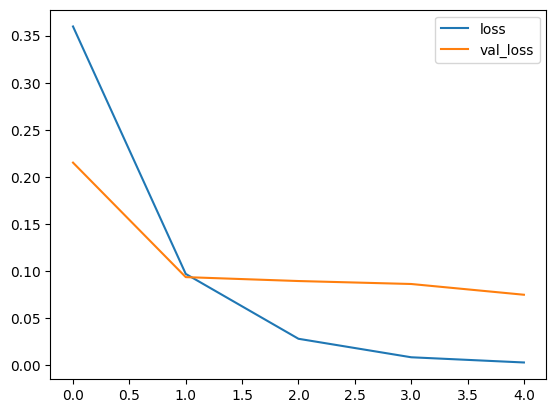

In [39]:
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

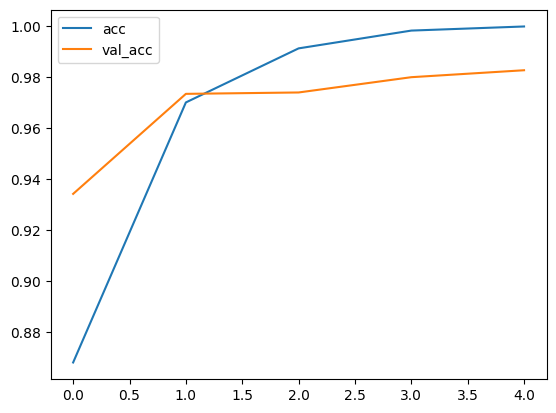

In [40]:
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()